# Foreword

### This notebook
In this notebook we plot the combination of L3 dynamic spectrum of the radio flux of FIELDS/LFR and HFR, using spacepy pycdf.
### Find data
I downloaded data directly from [here](https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/)

### Setup
My conda environment is running with:
- Python 3.12.7
- spacepy 0.7.0

In [1]:
import sys
print(sys.version)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


### History
Last run on May 13 2026 by S. Musset

# Open files and extract PSD

In [2]:
from matplotlib import pyplot as plt
import numpy as np
from spacepy import pycdf

In [3]:
file_lfr = '..\\..\\..\\data\\FIELDS\\psp_fld_l3_rfs_lfr_20250326_v00.cdf'
file_hfr = '..\\..\\..\\data\\FIELDS\\psp_fld_l3_rfs_hfr_20250326_v03.cdf'

Load the cdf files in a variables

In [4]:
data_lfr = pycdf.CDF(file_lfr)
data_hfr = pycdf.CDF(file_hfr)

In [5]:
psd_lfr = data_lfr['psp_fld_l3_rfs_lfr_PSD_SFU']

In [6]:
psd_hfr = data_hfr['psp_fld_l3_rfs_hfr_PSD_SFU']

In [7]:
time_lfr = data_lfr['epoch_lfr_stokes']
time_hfr = data_hfr['epoch_hfr_stokes']

In [8]:
freq_lfr = data_lfr['frequency_lfr_stokes']
freq_hfr = data_hfr['frequency_hfr_stokes']

# Plot dynamic spectra, together

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
from matplotlib import ticker
import datetime

In [10]:
z_lfr = np.transpose(np.array(psd_lfr))
x_lfr, y_lfr = np.meshgrid(time_lfr, freq_lfr[0]/1e6)

In [11]:
z_hfr = np.transpose(np.array(psd_hfr))
x_hfr, y_hfr = np.meshgrid(time_hfr, freq_hfr[0]/1e6)

In [12]:
# change the time display
locator = mdates.AutoDateLocator(minticks=3, maxticks=9)
formatter = mdates.ConciseDateFormatter(locator, show_offset=False)

## Plot the whole day

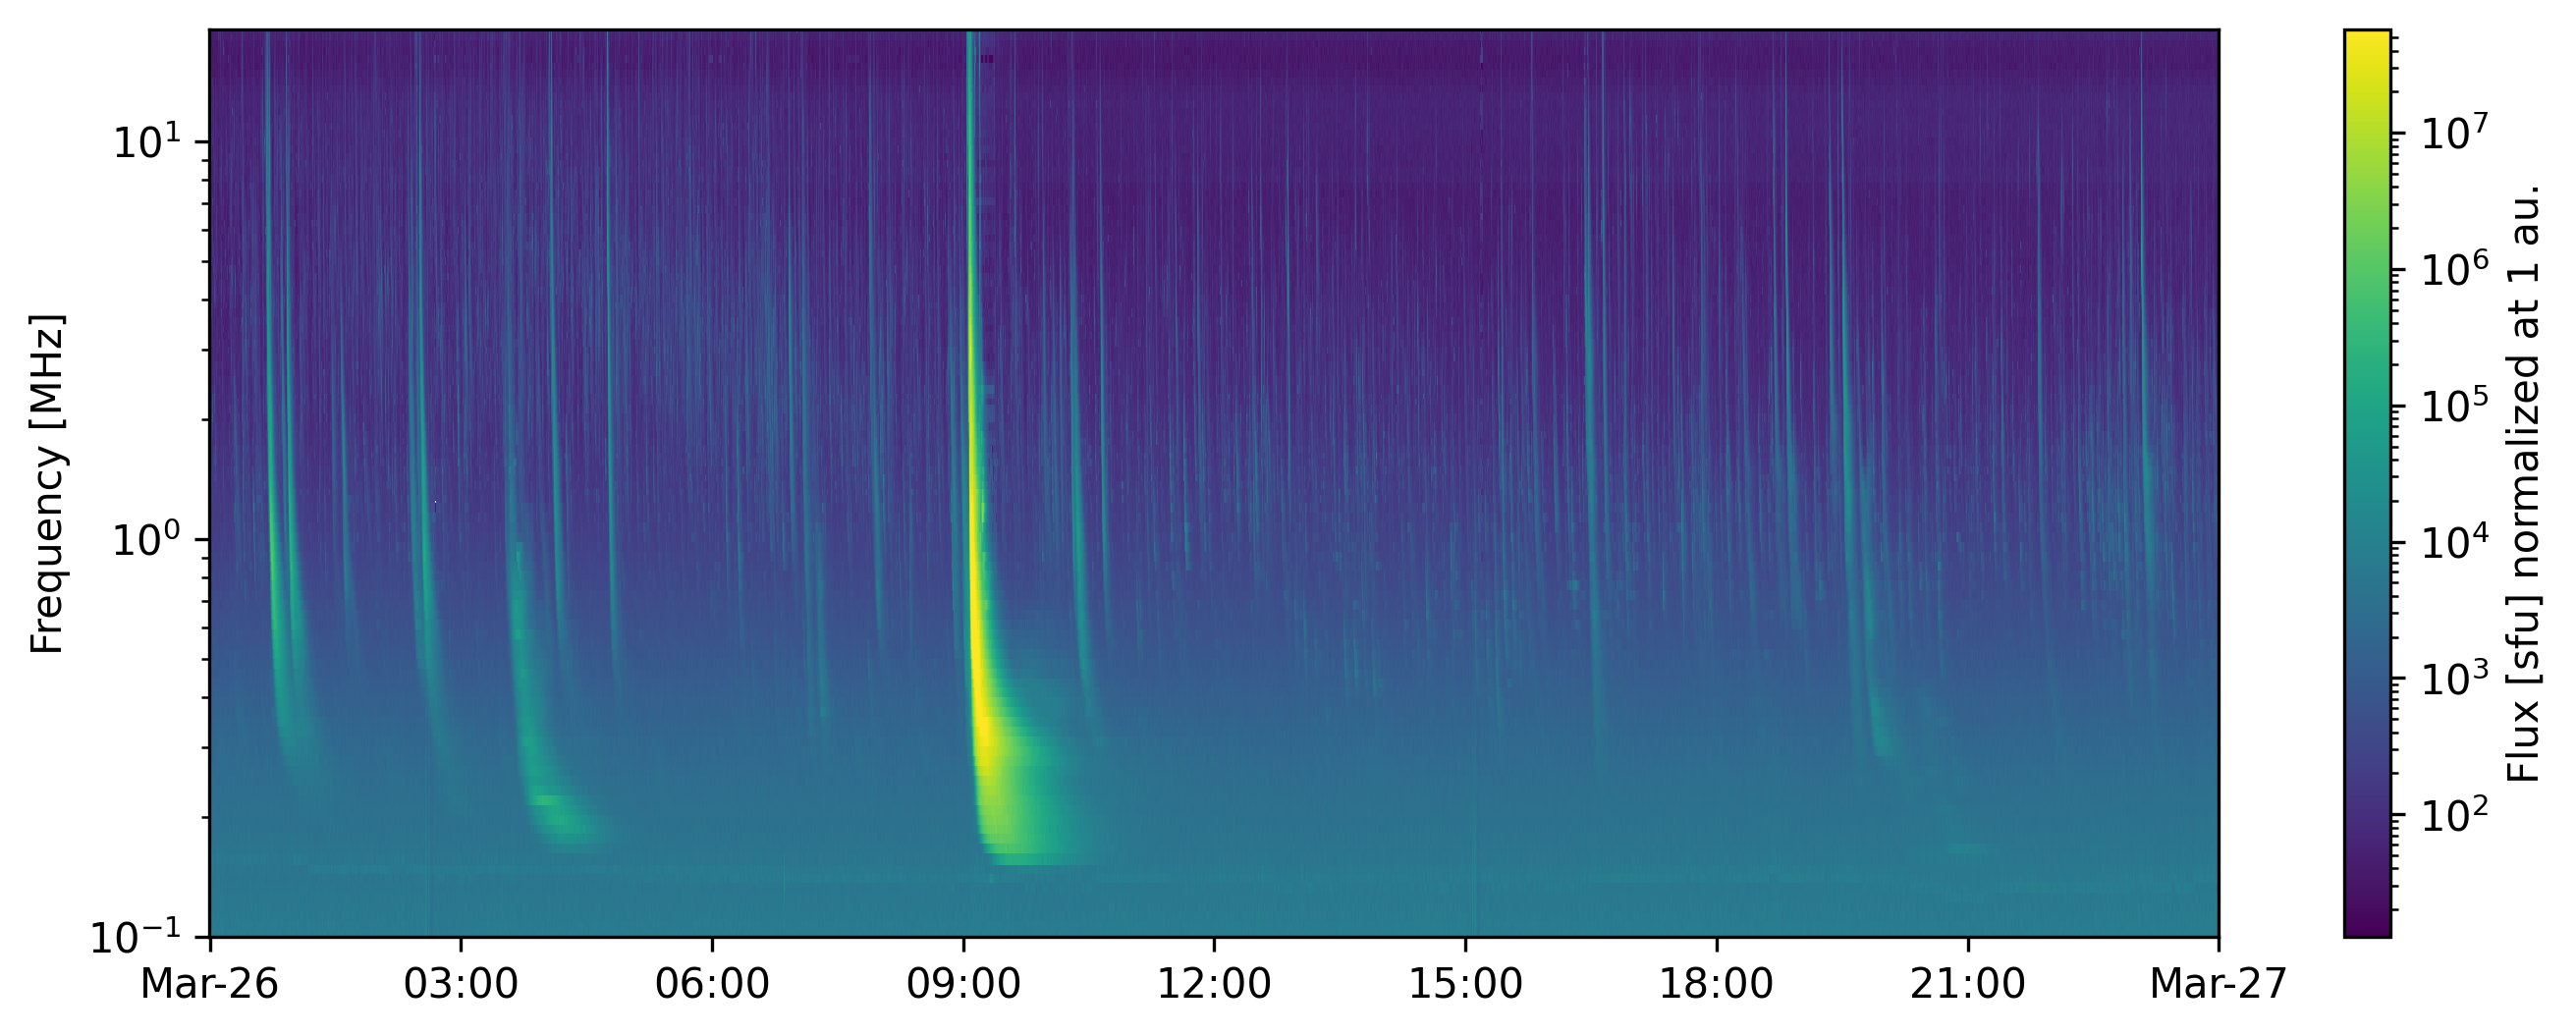

In [13]:
fig, axs = plt.subplots(nrows=1, sharex=True, sharey=False, figsize = (11, 4), dpi=300) 

# Remove horizontal space between axes
fig.subplots_adjust(hspace=0.)

# plot data
a = axs.pcolormesh(x_hfr, y_hfr, z_hfr, norm=LogNorm(vmin=z_hfr.min(), vmax=z_hfr.max()))  
b = axs.pcolormesh(x_lfr, y_lfr, z_lfr, norm=LogNorm(vmin=z_hfr.min(), vmax=z_hfr.max()))

# log scale
axs.set_yscale('log')
# label
axs.set_ylabel('Frequency [MHz]', fontsize=10)
# select frequency limits
axs.set_ylim(0.1, y_hfr.max())

# time axis
axs.xaxis.set_major_locator(locator)
axs.xaxis.set_major_formatter(formatter)
# colorbar
cb = fig.colorbar(a)# cax=cax)  #producing the colorbar
cb.set_label(label= 'Flux [sfu] normalized at 1 au.')

plt.show()

## Zoom on the strongest type III

In [14]:
time1 = datetime.datetime(2025,3,26,8,30,0)
time2 = datetime.datetime(2025,3,26,10,30,0)

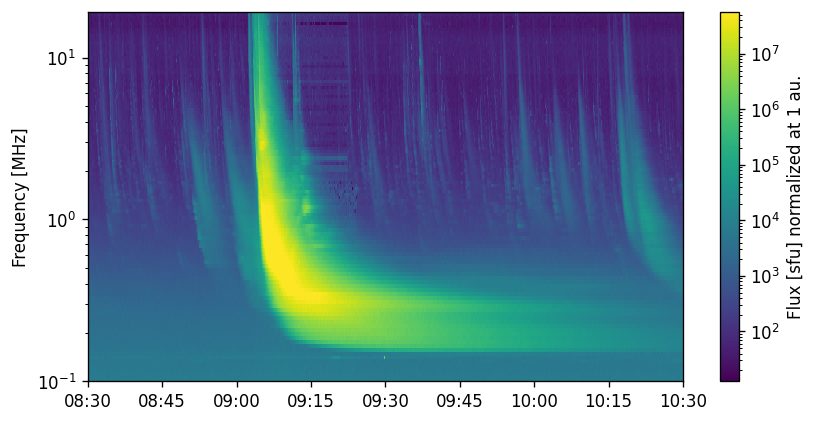

In [15]:
fig, axs = plt.subplots(nrows=1, sharex=True, sharey=False, figsize = (8, 4), dpi=120) 

# Remove horizontal space between axes
fig.subplots_adjust(hspace=0.)

# plot data
a = axs.pcolormesh(x_hfr, y_hfr, z_hfr, norm=LogNorm(vmin=z_hfr.min(), vmax=z_hfr.max()))  
b = axs.pcolormesh(x_lfr, y_lfr, z_lfr, norm=LogNorm(vmin=z_hfr.min(), vmax=z_hfr.max()))

# log scale
axs.set_yscale('log')
# label
axs.set_ylabel('Frequency [MHz]', fontsize=10)
# select frequency limits
axs.set_ylim(0.1, y_hfr.max())
# select time limits
axs.set_xlim(time1, time2)
# time axis
axs.xaxis.set_major_locator(locator)
axs.xaxis.set_major_formatter(formatter)
# colorbar
cb = fig.colorbar(a)# cax=cax)  #producing the colorbar
cb.set_label(label= 'Flux [sfu] normalized at 1 au.')

plt.show()